In [57]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib

data = pd.read_csv("data.csv")
data

,Test,CPU,DPU,M_C2D,M_D2C,UPMEM,U_C2D,U_D2C
0,HST-S,2.922,301.329,82.772,0.286,129.757,15.797,0.158
1,HST-L,3.569,520.058,79.244,0.341,436.494,14.623,0.154
2,RED,7.731,415.224,289.569,NaN,154.073,92.994,NaN
3,SCAN-SSA,2005.502,907.988,183.024,837.772,286.303,443.957,804.001
4,SCAN-RSS,28.300,913.442,185.200,915.286,234.249,59.095,141.952
5,TRNS,22.236,1485.280,10305.093,644.958,416.274,6842.449,62.648
6,SEL,21.125,602.101,357.098,1577.972,137.953,58.769,74.981
7,UNI,24.631,479.751,345.531,2261.717,95.413,57.333,128.431
8,BS,0.002,128.768,134.312,0.209,0.472,32.964,0.100
9,TS,44.827,251.313,4.196,0.185,79.837,3.618,1.268


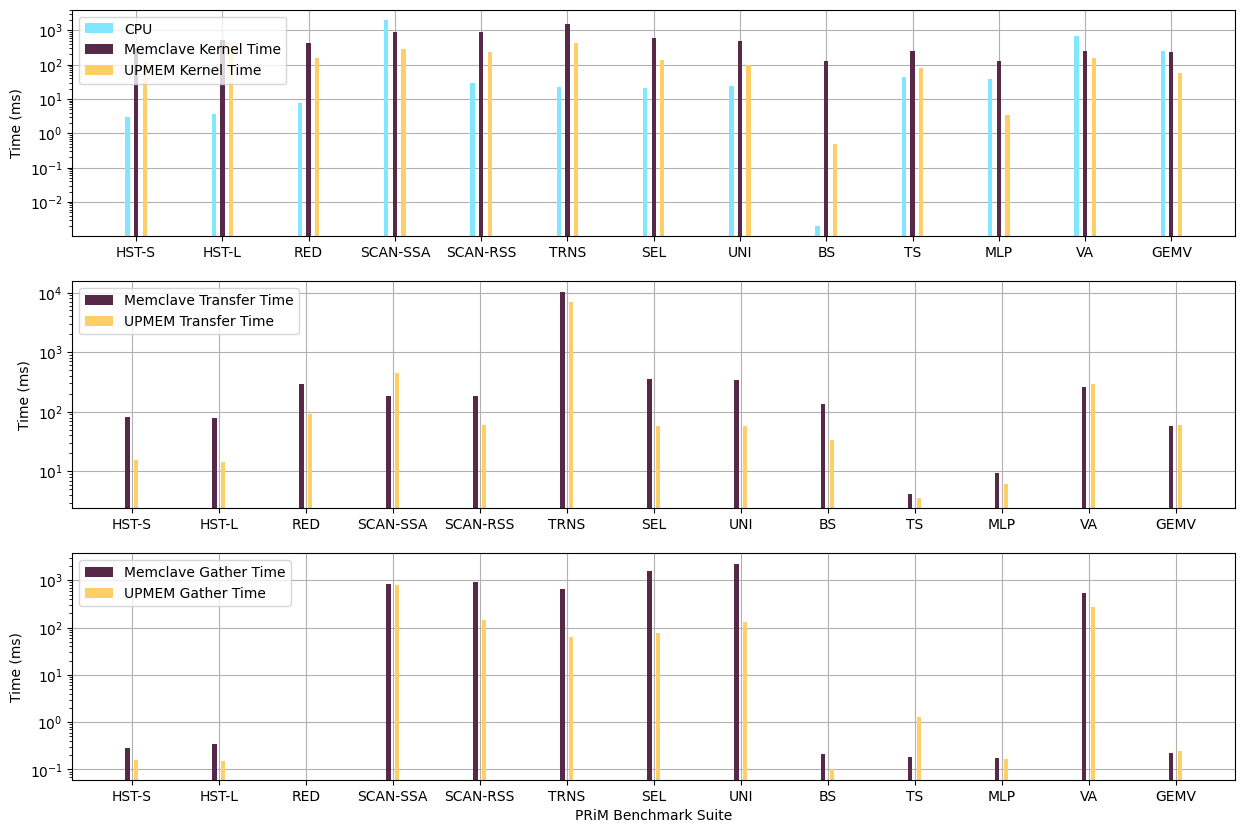

In [66]:
fig, ax = plt.subplots(nrows = 3, figsize = (15, 10))
cm = matplotlib.colormaps["managua"].resampled(3)

color_cpu = cm(0.9)
color_memclave = cm(0.6)
color_upmem = cm(0.3)

lwdth = 0.05
ldstmi = 0.1
ldstmj = 1.0

x = np.linspace(0, len(data["Test"]) - 1, len(data["Test"])) * ldstmj
x_name = list(data["Test"])
y_kernel = np.zeros(shape=(3, len(x_name)))
y_transfer = np.zeros(shape=(3, len(x_name)))
y_gather = np.zeros(shape=(3, len(x_name)))

for i, test in enumerate(x_name):
    y_kernel[0, i] = data[data["Test"] == test]["CPU"].mean()
    y_kernel[1, i] = data[data["Test"] == test]["DPU"].mean()
    y_kernel[2, i] = data[data["Test"] == test]["UPMEM"].mean()

    y_transfer[1, i] = data[data["Test"] == test]["M_C2D"].mean()
    y_transfer[2, i] = data[data["Test"] == test]["U_C2D"].mean()

    y_gather[1, i] = data[data["Test"] == test]["M_D2C"].mean()
    y_gather[2, i] = data[data["Test"] == test]["U_D2C"].mean()

ax[0].grid(True)
ax[0].set_axisbelow(True)
ax[0].bar(x - ldstmi, y_kernel[0,:], width = lwdth, color = color_cpu, label = "CPU")
ax[0].bar(x, y_kernel[1,:], width = lwdth, color = color_memclave, label = "Memclave Kernel Time")
ax[0].bar(x + ldstmi, y_kernel[2,:], width = lwdth, color = color_upmem, label = "UPMEM Kernel Time")
ax[0].set_yscale("log")
ax[0].set_xticks(x, x_name)
ax[0].set_ylabel("Time (ms)")
ax[0].legend(loc="upper left")

ax[1].grid(True)
ax[1].set_axisbelow(True)
ax[1].bar(x - ldstmi / 2, y_transfer[1,:], width = lwdth, color = color_memclave, label = "Memclave Transfer Time")
ax[1].bar(x + ldstmi / 2, y_transfer[2,:], width = lwdth, color = color_upmem, label = "UPMEM Transfer Time")
ax[1].set_yscale("log")
ax[1].set_xticks(x, x_name)
ax[1].set_ylabel("Time (ms)")
ax[1].legend(loc="upper left")

ax[2].grid(True)
ax[2].set_axisbelow(True)
ax[2].bar(x - ldstmi / 2, y_gather[1,:], width = lwdth, color = color_memclave, label = "Memclave Gather Time")
ax[2].bar(x + ldstmi / 2, y_gather[2,:], width = lwdth, color = color_upmem, label = "UPMEM Gather Time")
ax[2].set_yscale("log")
ax[2].set_xticks(x, x_name)
ax[2].set_xlabel("PRiM Benchmark Suite")
ax[2].set_ylabel("Time (ms)")
ax[2].legend(loc="upper left")

plt.show()